# Day 4–5 — Churn EDA

Goal: visualise churn patterns across contract type, tenure, monthly charges, and payment method.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'stayed': '#5DCAA5', 'churned': '#D85A30'}

df = pd.read_csv('../data/processed/cleaned_churn.csv')
print(f'Loaded: {df.shape}')

Loaded: (7032, 20)


## 1 — Overall churn rate

In [2]:
# Already saved in notebook 02 — quick re-display
churn_rate = df['Churn'].mean()
print(f'Overall churn rate: {churn_rate:.1%}')

Overall churn rate: 26.6%


## 2 — Churn by Contract type

         Contract  Churn Rate
0  Month-to-month    0.427097
1        One year    0.112772
2        Two year    0.028487


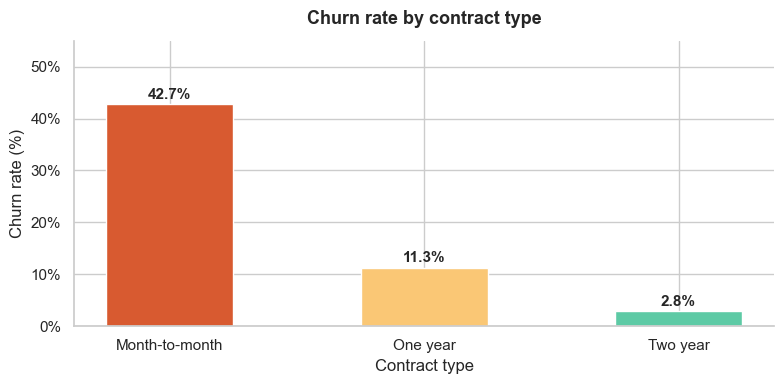

Saved → images/contract_vs_churn.png


In [3]:
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']
print(contract_churn)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate'] * 100,
              color=['#D85A30', '#FAC775', '#5DCAA5'], edgecolor='white', width=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Churn rate by contract type', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Contract type')
ax.set_ylabel('Churn rate (%)')
ax.set_ylim(0, 55)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
sns.despine()

plt.tight_layout()
plt.savefig('../images/contract_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/contract_vs_churn.png')

## 3 — Tenure distribution by churn

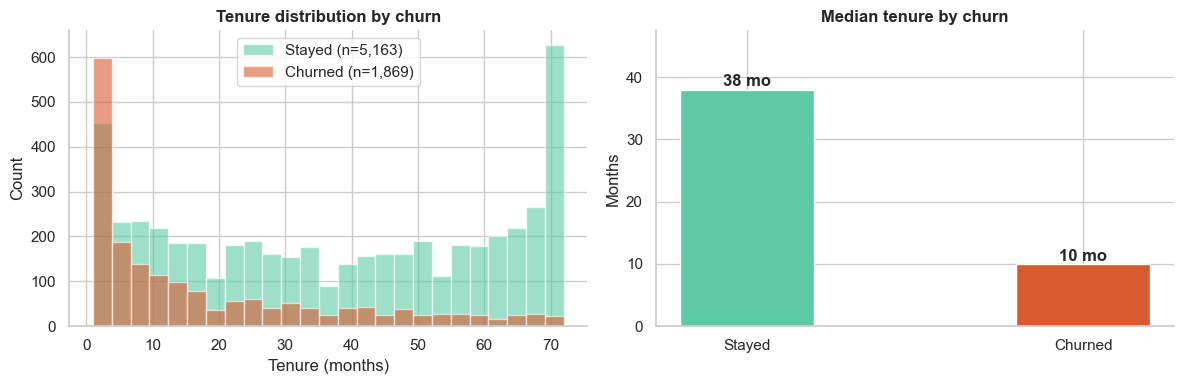

Saved → images/tenure_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE plot
for label, color, group in [('Stayed', '#5DCAA5', 0), ('Churned', '#D85A30', 1)]:
    subset = df[df['Churn'] == group]['tenure']
    axes[0].hist(subset, bins=25, alpha=0.6, color=color, label=f'{label} (n={len(subset):,})', edgecolor='white')

axes[0].set_title('Tenure distribution by churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()
sns.despine(ax=axes[0])

# Median tenure comparison
medians = df.groupby('Churn')['tenure'].median()
axes[1].bar(['Stayed', 'Churned'], medians.values, color=['#5DCAA5', '#D85A30'], edgecolor='white', width=0.4)
for i, v in enumerate(medians.values):
    axes[1].text(i, v + 0.5, f'{v:.0f} mo', ha='center', fontweight='bold')
axes[1].set_title('Median tenure by churn', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Months')
axes[1].set_ylim(0, medians.max() * 1.25)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../images/tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/tenure_distribution.png')

## 4 — Monthly charges by churn

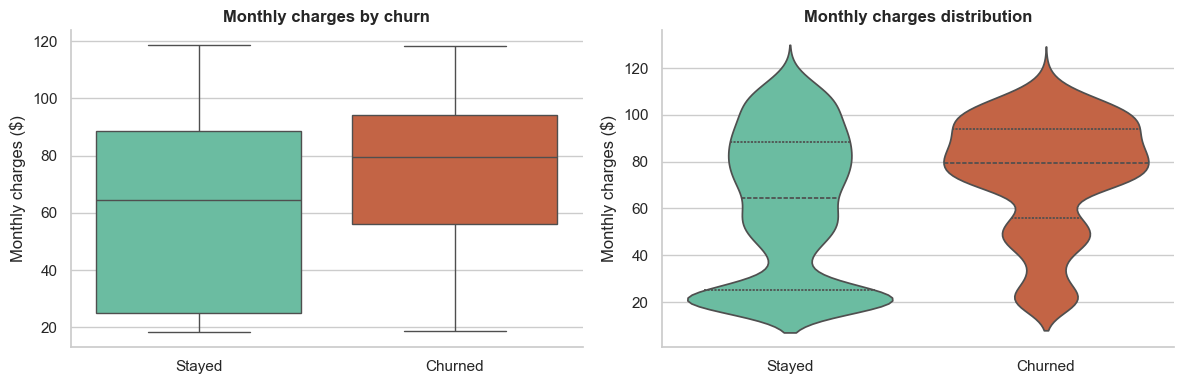

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
df['Churn_label'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})
sns.boxplot(data=df, x='Churn_label', y='MonthlyCharges',
            palette={'Stayed': '#5DCAA5', 'Churned': '#D85A30'},
            order=['Stayed', 'Churned'], ax=axes[0])
axes[0].set_title('Monthly charges by churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monthly charges ($)')
sns.despine(ax=axes[0])

# Violin
sns.violinplot(data=df, x='Churn_label', y='MonthlyCharges',
               palette={'Stayed': '#5DCAA5', 'Churned': '#D85A30'},
               order=['Stayed', 'Churned'], inner='quartile', ax=axes[1])
axes[1].set_title('Monthly charges distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Monthly charges ($)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../images/monthly_charges_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Payment method vs churn

PaymentMethod
Credit card (automatic)      15.3%
Bank transfer (automatic)    16.7%
Mailed check                 19.2%
Electronic check             45.3%
Name: Churn, dtype: str


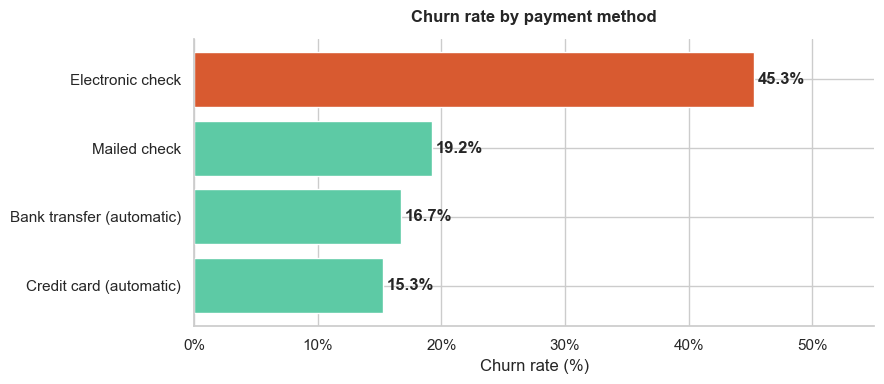

In [6]:
pay_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=True)
print(pay_churn.map('{:.1%}'.format))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#5DCAA5' if v < 0.30 else '#FAC775' if v < 0.40 else '#D85A30' for v in pay_churn.values]
bars = ax.barh(pay_churn.index, pay_churn.values * 100, color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontweight='bold')

ax.set_title('Churn rate by payment method', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Churn rate (%)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, 55)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('../images/payment_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Correlation heatmap (numeric features)

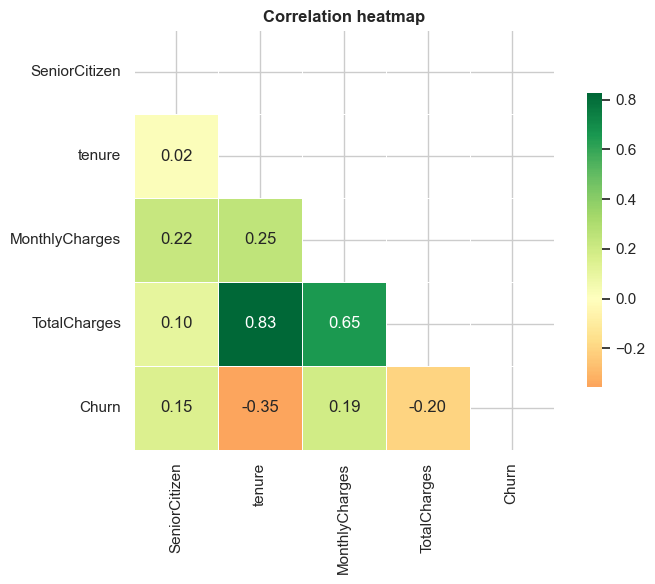

In [7]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Key EDA findings

1. **Month-to-month contracts churn at ~43%** vs 11% (1-year) and 3% (2-year). Contract type is the strongest predictor.
2. **Churned customers have much lower tenure** (median ~10 months vs ~38 months for stayers). New customers are highest risk.
3. **Churned customers pay more** per month on average (~$74 vs $61). High-paying customers with no commitment are volatile.
4. **Electronic check payment** has the highest churn rate (~45%). May correlate with no automatic commitment.
5. **Tenure and TotalCharges are highly correlated** (>0.8) — we may want to use only one of them to avoid multicollinearity.